In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, kron
from scipy.sparse.linalg import expm_multiply

In [2]:
# a single point is arranged along the last axis [i_1,i_2,...,i_d,:]
def delta_multivar(x, omega):
    # computes multivariate delta function on each point
    assert omega > 0
    return np.prod(delta_1d(x, omega), axis=-1)
def delta_1d(x, omega):
    assert omega > 0
    return (np.abs(x) <= omega) *  beta_2(x / omega) / omega
def beta(x):
    return 1 - np.abs(x)
def beta_2(x):
    return (1 + np.cos(np.pi * x)) / 2

## scalar nonlinear hyperbolic pde 

### burger's equation

In [3]:
M = 1
N = 256
h = 1/N
m = 7
omega = m * h

In [4]:
x, p = np.meshgrid(np.linspace(0, 1, N), np.linspace(0, 1, N), indexing='ij')

In [5]:
mu = 0.5
sigma = 0.15
u_0 = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / 1.1 #/ (sigma * np.sqrt(2 * np.pi))

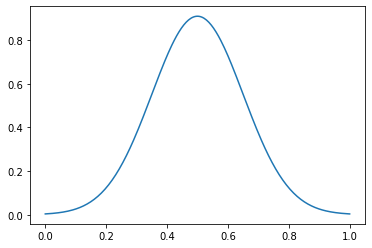

In [6]:
plt.plot(x[:,0], u_0[:,0])
plt.show()

In [7]:
psi_0 = delta_1d(p - u_0, omega)

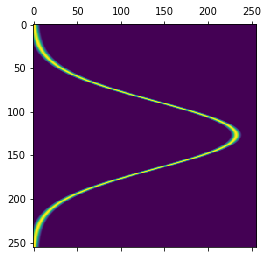

In [8]:
plt.matshow(psi_0)
plt.show()

In [9]:
psi = psi_0

In [10]:
discrete_gradient = diags([-np.ones(N-1), np.zeros(N), np.ones(N-1)], offsets=[-1,0,1]) / (2 * h)

In [11]:
T = 0.5
N_t = 5 # time points

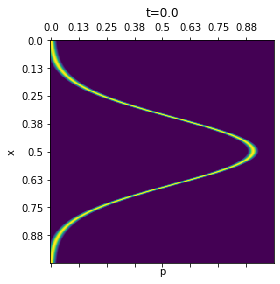

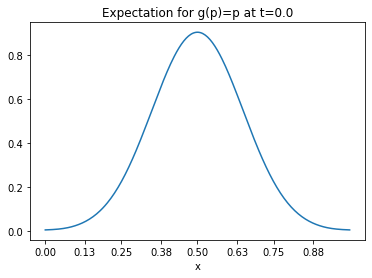

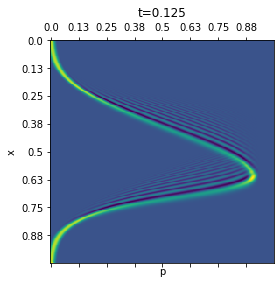

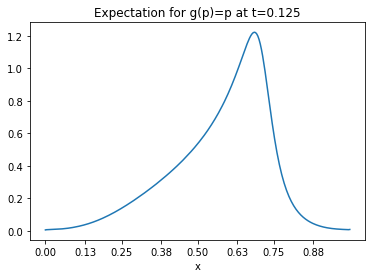

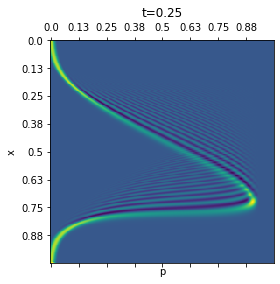

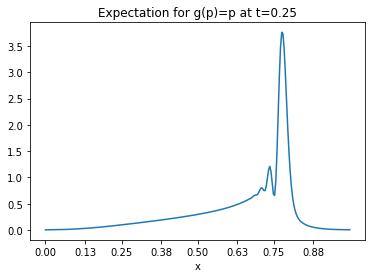

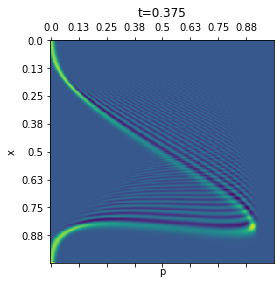

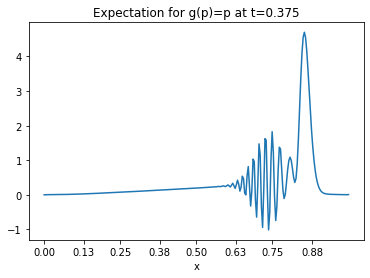

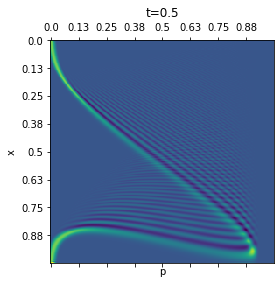

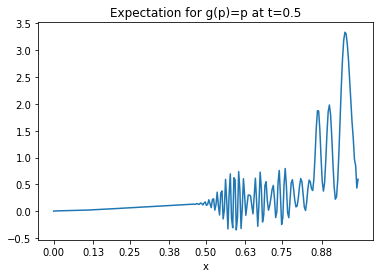

In [16]:
for t in np.linspace(0, T, N_t):
    psi = np.zeros_like(psi_0)
    for i,p_val in enumerate(np.linspace(0, 1, N)):
        psi[:,i] = expm_multiply(-p_val * discrete_gradient * t, psi_0[:,i])
    plt.matshow(psi)
    plt.title(f"t={t}")
    plt.ylabel("x")
    plt.yticks(np.arange(N, step=32), np.round(x[::32,0], decimals=2))
    
    plt.xlabel("p")
    plt.xticks(np.arange(N, step=32), np.round(p[0,::32], decimals=2))
    plt.savefig(f"level_set_{t}.png", dpi=100, facecolor="white")
    plt.show()

    exp_g = np.average(p * psi, axis=1)
    plt.plot(x[:,0], exp_g)
    plt.title(f"Expectation for g(p)=p at t={t}")
    plt.xlabel("x")
    plt.xticks(np.round(x[::32,0], decimals=2))
    plt.show()

In [413]:
# g is a function of p (density, momentum, or energy corresponding to the 0th, 1st, and 2nd moment)
# g = p